# MLE over time, v7: one beam with loss (`data_mle_over_time_loss_1*`)

Analysis of the four v7 runs of `multiparameter_trotter_v7_loss_least_squares_over_time.py`
(model note: `latex/open_system_model.tex`, sections "One beam" and "Loss"). One off-resonant probe
produces the tensor shift $\beta J_z^2$, scatters photons and is read out. Per scattered photon
(Cs D2, $F=3$, from `cs_light_shift_scattering_ratios.py`): tensor shift $\beta = 7.4\,\gamma_s$,
within-manifold spin flips at $0.0055\,\gamma_s$, and Raman loss to $F=4$ with rate operator
$K_L = \gamma_s(0.204 + 0.0107\,J_z^2)$, which is 97 % of the signal relaxation. The sweep variable
is $\beta$; $\gamma_s = \beta/7.4$ and the shot noise $\sigma^2 = 1/((b/a)^2\,\mathrm{OD}_{\rm res} N_a\,\delta t\,\gamma_s)$
follow from it.

| set | $\mathrm{OD}_{\rm res}$ | $J_z^2$ term | role |
|---|---|---|---|
| `loss_1` | 140 | on | same operating point as `onebeam_1` (its $\mathrm{OD}_{\rm eff}=10$), now with loss |
| `loss_1_notensor` | 140 | off | the "$\beta=0$" reference: identical beam, no nonlinearity |
| `loss_1_od10` | 10 | on | free-space cloud ($2\times10^5$ atoms in a 50 µm beam) |
| `loss_1_od10_notensor` | 10 | off | its reference |

All sets: $\beta\in\{0.5,1,2,5,10,20\}$, $T=14/\Omega$, 300 fits per ($\beta$, cutoff), 20 tasks
(one $w_{\rm true}$ draw each), same seeds across the four sets so the comparisons are paired.

Two Cramér–Rao bounds are saved per run. $[\mathbb{E}F]^{-1}$ (`fisher.npy`) is the bound for a
fixed control; $\mathbb{E}[F_i^{-1}]$ (`fisher_inv_realavg.npy`) is the bound the simulated
per-realization estimator can reach (Jensen, see the v6 notebook). Dashed lines below are the
reachable one, dotted the naive one. As in v5/v6, the cost-band filter drops the few percent of fits
that converged to a local minimum, and everything is averaged over the 20 tasks in-notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
%matplotlib inline

SETS = {
    'OD 140, tensor on':  Path('data_mle_over_time_loss_1'),
    'OD 140, tensor off': Path('data_mle_over_time_loss_1_notensor'),
    'OD 10, tensor on':   Path('data_mle_over_time_loss_1_od10'),
    'OD 10, tensor off':  Path('data_mle_over_time_loss_1_od10_notensor'),
}
ONEBEAM = Path('data_mle_over_time_onebeam_1')   # v6 run: same beta, same eta_total ~ 30, same noise as OD 140, spin-flip channel only

labels_omega = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
beta_colors = ['#2a78d6', '#1baf7a', '#eda100', '#e34948', '#008300', '#4a3aa7', '#e87ba4', '#eb6834']
dt = 1e-3
n_fits = 300
t_steps_run = 14000

def load_npy(root_folder):
    return {file.stem: np.load(file) for file in Path(root_folder).rglob('*.npy')}

def task_dirs(root):
    return sorted((p for p in Path(root).iterdir() if p.is_dir() and p.name.startswith('task_')),
                  key=lambda p: int(p.name.split('_')[1]))

def cost_floor_and_band(checkpoint_times, sn_sd_array, k=5.0):
    '''Shot-noise cost floor and 5-sigma chi-square band, per beta: (n_beta, n_time).'''
    n_sub = np.array([np.sum(np.linspace(0, t_steps_run, t_steps_run, dtype=int) <= tc) for tc in checkpoint_times])
    sd2 = np.asarray(sn_sd_array)[:, None]**2
    return 0.5 * sd2 * n_sub[None, :], 0.5 * sd2 * (n_sub + k*np.sqrt(2*n_sub))[None, :]

def filter_cost_band(run):
    '''Fits above the 5-sigma band -> NaN; bias/variance from the survivors. Returns (1,n_beta,n_time,3) x2 and removed fraction.'''
    _, band = cost_floor_and_band(run['time_cutoffs_array'], run['sn_sd_array'])
    mask_bad = run['cost_est'] > band[None, :, :, None]
    w_f = np.where(mask_bad[..., None], np.nan, run['w_est'])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        bias = np.nanmean(w_f, axis=3) - run['w_true'][:, None, None, :]
        variance = np.nanvar(w_f, axis=3, ddof=1)
    return bias, variance, mask_bad.mean(axis=-1)

def aggregate(root):
    '''Per-task filtered statistics and both Cramer-Rao bounds, averaged over the task folders of one run.'''
    tasks = task_dirs(root); runs = [load_npy(p) for p in tasks]; ref = runs[0]
    per = {k: [] for k in ['bias_f', 'var_f', 'removed_f', 'crb', 'crb_ra', 'fit', 'fit_ra', 'accept', 'w_true']}
    for r in runs:
        assert np.array_equal(r['beta_array'], ref['beta_array']) and np.array_equal(r['time_cutoffs_array'], ref['time_cutoffs_array'])
        b, v, rem = filter_cost_band(r)
        per['bias_f'].append(b[0]); per['var_f'].append(v[0]); per['removed_f'].append(rem[0])
        per['crb'].append(np.diagonal(np.linalg.inv(r['fisher'][0]), axis1=-2, axis2=-1))
        per['fit'].append(r['fisher_inv_trace'][0])
        if 'fisher_inv_realavg' in r:
            per['crb_ra'].append(np.diagonal(r['fisher_inv_realavg'][0], axis1=-2, axis2=-1))
            per['fit_ra'].append(r['fisher_inv_realavg_trace'][0])
        per['accept'].append(r['accept_fraction'][0]); per['w_true'].append(r['w_true'][0])
    per = {k: np.array(v) for k, v in per.items() if len(v)}
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        avg = {k: np.nanmean(v, axis=0) for k, v in per.items() if k != 'w_true'}
    return dict(name=Path(root).name, ref=ref, per=per, avg=avg, n_tasks=len(tasks),
                beta=ref['beta_array'], gamma=ref['gamma_array'], sn=ref['sn_sd_array'],
                times=ref['time_cutoffs_array']*dt, tot_var=avg['var_f'].sum(axis=2),
                tot_fit=avg['fit'], tot_fit_ra=avg.get('fit_ra'))

def beta_label(d, b_idx):
    return fr'$\beta={d["beta"][b_idx]:g}$, $\gamma={d["gamma"][b_idx]:.3g}$, $\sigma={d["sn"][b_idx]:.3g}$'

def time_to_target(curve, times, target):
    '''Earliest time after which curve stays below target (log-interpolated); NaN if never within the run.'''
    above = curve > target
    if not above.any():
        return times[0]
    i = int(np.max(np.where(above)[0]))
    if i + 1 >= len(times):
        return np.nan
    f = (np.log(curve[i]) - np.log(target)) / (np.log(curve[i]) - np.log(curve[i + 1]))
    return times[i] + f * (times[i + 1] - times[i])

D = {name: aggregate(root) for name, root in SETS.items()}
OB = aggregate(ONEBEAM)
main = D['OD 140, tensor on']
beta_values, checkpoint_times, times = main['beta'], main['ref']['time_cutoffs_array'], main['times']
for name, d in D.items():
    assert np.array_equal(d['beta'], beta_values) and np.array_equal(d['times'], times)
print({name: d['n_tasks'] for name, d in D.items()}, '| onebeam_1:', OB['n_tasks'])
r = main['ref']
display(pd.DataFrame({'gamma_s (total scattering)': r['gamma_s_array'], 'loss rate <K_L>': r['loss_rate_scs_array'],
                      'spin-flip rate': r['gamma_sf_array'], 'gamma = loss + flips': r['gamma_array'],
                      '1/gamma (Omega t)': 1/r['gamma_array'], 'survival at T': np.exp(-r['loss_rate_scs_array']*times[-1]),
                      'sigma, OD 140': main['sn'], 'sigma, OD 10': D['OD 10, tensor on']['sn']},
                     index=pd.Index(beta_values, name='beta')).round(4))


{'OD 140, tensor on': 20, 'OD 140, tensor off': 20, 'OD 10, tensor on': 20, 'OD 10, tensor off': 20} | onebeam_1: 20


,gamma_s (total scattering),loss rate <K_L>,spin-flip rate,gamma = loss + flips,1/gamma (Omega t),survival at T,"sigma, OD 140","sigma, OD 10"
beta,,,,,,,,
0.5,0.0678,0.0149,0.0004,0.0153,65.3514,0.8114,0.1807,0.6760
1.0,0.1357,0.0299,0.0007,0.0306,32.6757,0.6584,0.1277,0.4780
2.0,0.2714,0.0597,0.0015,0.0612,16.3378,0.4334,0.0903,0.3380
5.0,0.6784,0.1493,0.0037,0.1530,6.5351,0.1237,0.0571,0.2138
10.0,1.3569,0.2986,0.0075,0.3060,3.2676,0.0153,0.0404,0.1512
20.0,2.7137,0.5972,0.0149,0.6121,1.6338,0.0002,0.0286,0.1069


## Variance against both bounds, main run (OD 140, tensor on)

Solid: filtered Monte Carlo variance. Dashed: reachable bound $\mathbb{E}[F_i^{-1}]$. Dotted: naive
bound $[\mathbb{E}F]^{-1}$. With loss the signal simply shrinks as the survival probability, so the
strong-probe curves flatten once $\gamma t \gtrsim 1$ ($1/\gamma$ is in the table above).


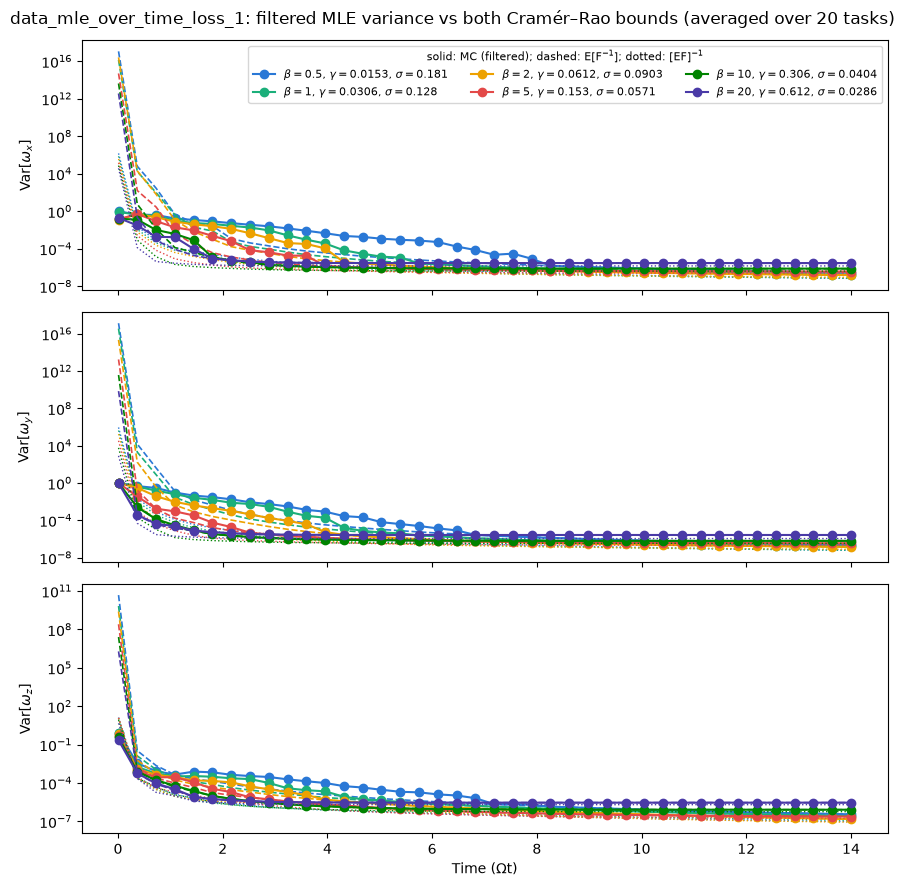

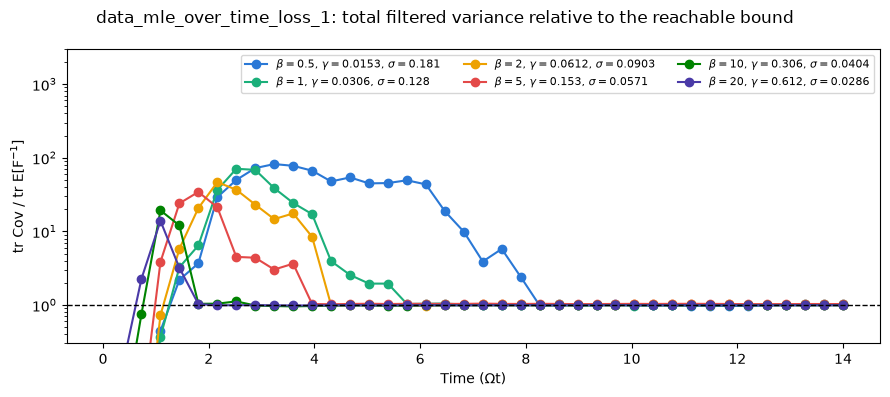

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for j, lab in enumerate(labels_omega):
    for b_idx, beta in enumerate(beta_values):
        c = beta_colors[b_idx % len(beta_colors)]
        axes[j].semilogy(times, main['avg']['var_f'][b_idx][:, j], 'o-', color=c, label=beta_label(main, b_idx))
        axes[j].semilogy(times, main['avg']['crb_ra'][b_idx][:, j], '--', color=c, lw=1.2)
        axes[j].semilogy(times, main['avg']['crb'][b_idx][:, j], ':', color=c, lw=1.0)
    axes[j].set_ylabel(f'Var[{lab}]')
axes[0].legend(loc='upper right', ncol=3, fontsize=8, title='solid: MC (filtered); dashed: E[F$^{-1}$]; dotted: [EF]$^{-1}$', title_fontsize=8)
axes[-1].set_xlabel(r'Time ($\Omega$t)')
fig.suptitle(f'{main["name"]}: filtered MLE variance vs both Cramér–Rao bounds (averaged over {main["n_tasks"]} tasks)')
plt.tight_layout(); plt.show()

#Estimator efficiency: MC total variance over the reachable bound
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
for b_idx, beta in enumerate(beta_values):
    ax.semilogy(times, main['tot_var'][b_idx]/main['tot_fit_ra'][b_idx], 'o-', color=beta_colors[b_idx % len(beta_colors)], label=beta_label(main, b_idx))
ax.axhline(1, color='k', ls='--', lw=1); ax.set_ylabel(r'tr Cov / tr E[F$^{-1}$]'); ax.set_xlabel(r'Time ($\Omega$t)')
ax.set_ylim(0.3, 3e3); ax.legend(loc='upper right', ncol=3, fontsize=8)
fig.suptitle(f'{main["name"]}: total filtered variance relative to the reachable bound'); plt.tight_layout(); plt.show()


## All four runs: total variance and bounds vs time

One panel per run; per $\beta$: solid = filtered tr Cov, dashed = tr $\mathbb{E}[F^{-1}]$, dotted = tr $[\mathbb{E}F]^{-1}$.
Left column has the nonlinearity, right column the identical beam without it. Top row OD 140, bottom OD 10.


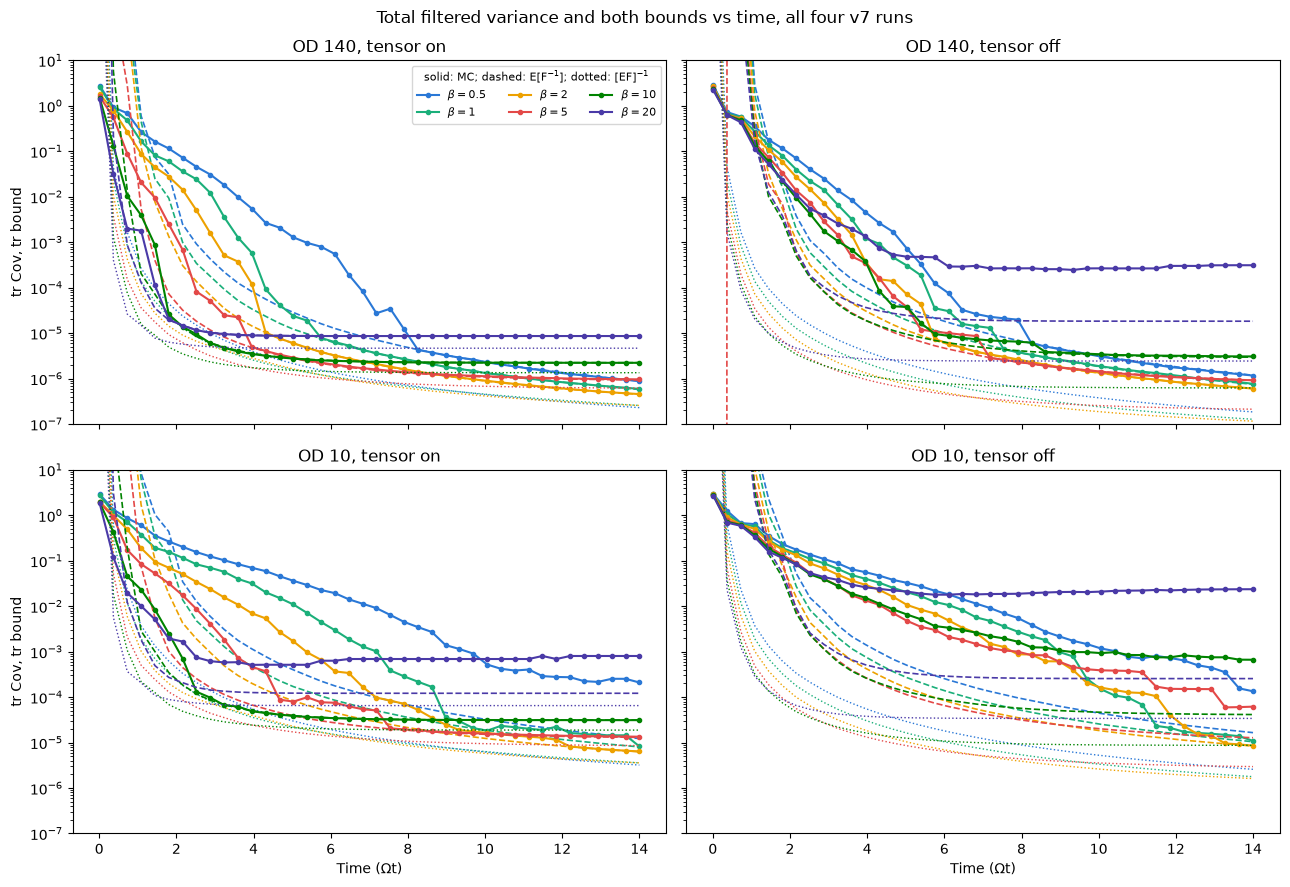

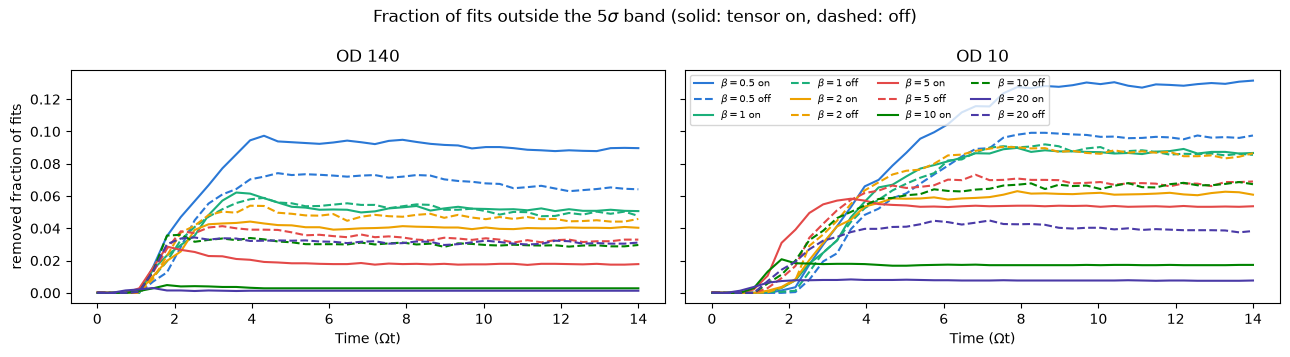

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey='row')
for ax, (name, d) in zip(axes.ravel(), D.items()):
    for b_idx, beta in enumerate(beta_values):
        c = beta_colors[b_idx % len(beta_colors)]
        ax.semilogy(times, d['tot_var'][b_idx], 'o-', color=c, ms=3, label=fr'$\beta={beta:g}$')
        ax.semilogy(times, d['tot_fit_ra'][b_idx], '--', color=c, lw=1.2)
        ax.semilogy(times, d['tot_fit'][b_idx], ':', color=c, lw=1.0)
    ax.set_title(name); ax.set_ylim(1e-7, 1e1)
axes[0, 0].legend(loc='upper right', ncol=3, fontsize=8, title='solid: MC; dashed: E[F$^{-1}$]; dotted: [EF]$^{-1}$', title_fontsize=8)
for ax in axes[:, 0]: ax.set_ylabel('tr Cov, tr bound')
for ax in axes[-1]: ax.set_xlabel(r'Time ($\Omega$t)')
fig.suptitle('Total filtered variance and both bounds vs time, all four v7 runs'); plt.tight_layout(); plt.show()

#Fits removed by the cost band, per run
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, od in zip(axes, ['OD 140', 'OD 10']):
    for b_idx, beta in enumerate(beta_values):
        c = beta_colors[b_idx % len(beta_colors)]
        ax.plot(times, D[f'{od}, tensor on']['avg']['removed_f'][b_idx], '-', color=c, label=fr'$\beta={beta:g}$ on')
        ax.plot(times, D[f'{od}, tensor off']['avg']['removed_f'][b_idx], '--', color=c, label=fr'$\beta={beta:g}$ off')
    ax.set_title(od); ax.set_xlabel(r'Time ($\Omega$t)')
axes[0].set_ylabel('removed fraction of fits'); axes[1].legend(ncol=4, fontsize=7)
fig.suptitle('Fraction of fits outside the $5\\sigma$ band (solid: tensor on, dashed: off)'); plt.tight_layout(); plt.show()


## Does the nonlinearity help? Tensor on vs off at equal $\beta$

Same beam, same seeds, same decoherence and shot noise; only the $J_z^2$ term differs. Ratios below 1
mean the nonlinearity helps. Solid: Monte Carlo total variance; dashed: reachable bound; dotted: naive
bound. The naive bound and the Monte Carlo answer can disagree because the nonlinear dynamics make the
information depend more strongly on the particular random control (the Jensen gap is larger with the
tensor term, see the tables of the previous section).


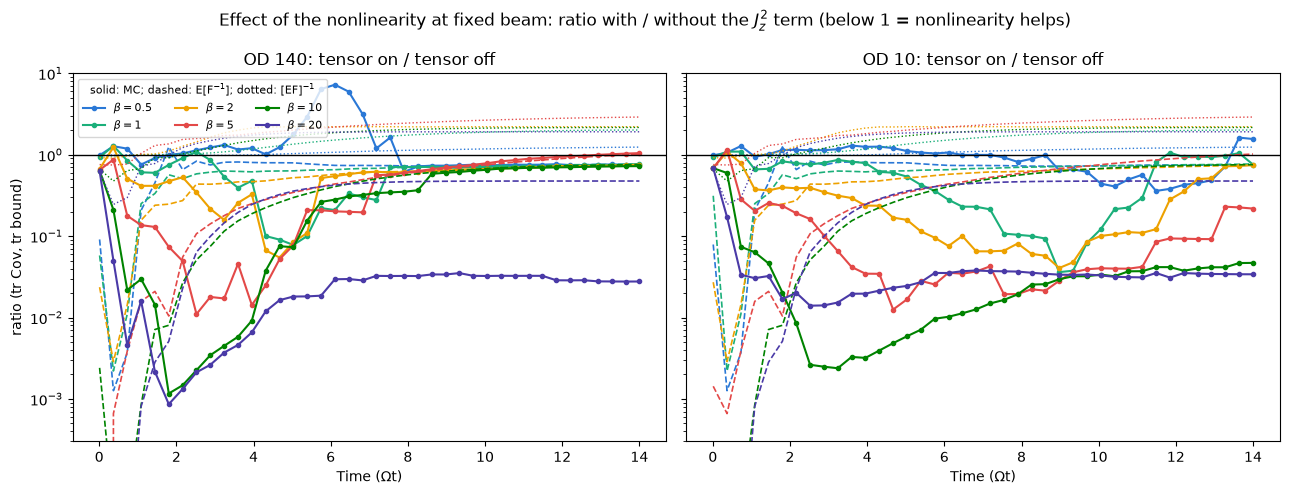

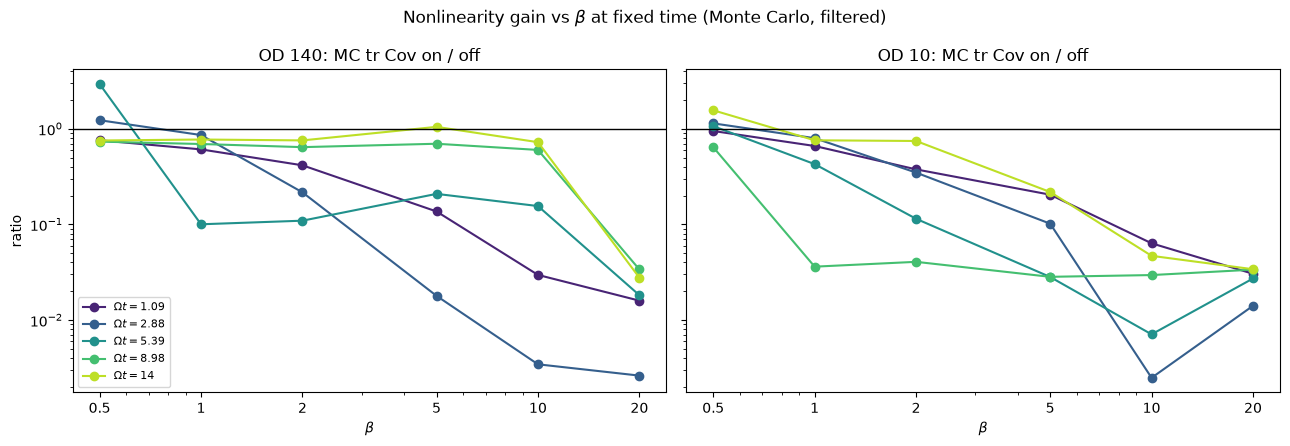

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, od in zip(axes, ['OD 140', 'OD 10']):
    on, off = D[f'{od}, tensor on'], D[f'{od}, tensor off']
    for b_idx, beta in enumerate(beta_values):
        c = beta_colors[b_idx % len(beta_colors)]
        ax.semilogy(times, on['tot_var'][b_idx]/off['tot_var'][b_idx], 'o-', color=c, ms=3, label=fr'$\beta={beta:g}$')
        ax.semilogy(times, on['tot_fit_ra'][b_idx]/off['tot_fit_ra'][b_idx], '--', color=c, lw=1.2)
        ax.semilogy(times, on['tot_fit'][b_idx]/off['tot_fit'][b_idx], ':', color=c, lw=1.0)
    ax.axhline(1, color='k', ls='-', lw=1); ax.set_title(f'{od}: tensor on / tensor off'); ax.set_xlabel(r'Time ($\Omega$t)'); ax.set_ylim(3e-4, 10)
axes[0].set_ylabel('ratio (tr Cov, tr bound)'); axes[0].legend(loc='upper left', ncol=3, fontsize=8, title='solid: MC; dashed: E[F$^{-1}$]; dotted: [EF]$^{-1}$', title_fontsize=8)
fig.suptitle('Effect of the nonlinearity at fixed beam: ratio with / without the $J_z^2$ term (below 1 = nonlinearity helps)')
plt.tight_layout(); plt.show()

#Same ratio at fixed times as a function of beta
time_idx_show = [3, 8, 15, 25, len(times) - 1]
tcol = plt.cm.viridis(np.linspace(0.1, 0.9, len(time_idx_show)))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, od in zip(axes, ['OD 140', 'OD 10']):
    on, off = D[f'{od}, tensor on'], D[f'{od}, tensor off']
    for c, ti in zip(tcol, time_idx_show):
        ax.loglog(beta_values, on['tot_var'][:, ti]/off['tot_var'][:, ti], 'o-', color=c, label=fr'$\Omega t={times[ti]:.3g}$')
    ax.axhline(1, color='k', lw=1); ax.set_title(f'{od}: MC tr Cov on / off'); ax.set_xlabel(r'$\beta$')
    ax.set_xticks(beta_values); ax.set_xticklabels([f'{b:g}' for b in beta_values]); ax.xaxis.set_minor_formatter(plt.NullFormatter())
axes[0].set_ylabel('ratio'); axes[0].legend(fontsize=8)
fig.suptitle('Nonlinearity gain vs $\\beta$ at fixed time (Monte Carlo, filtered)'); plt.tight_layout(); plt.show()


## Best probe strength vs time, and time to reach a target precision

For each run: the $\beta$ with the smallest filtered total variance at each cutoff, and the time after
which the total variance stays below a target (log-interpolated, dash = never within $T=14/\Omega$).
The last table summarizes, per run and target, the best time over $\beta$ and the $\beta$ that achieves it.


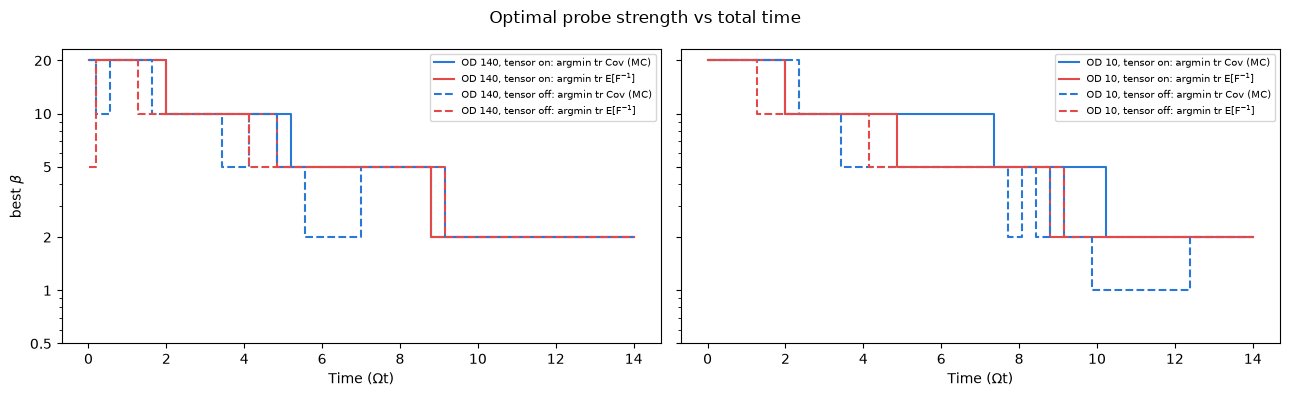

target,1e-02,1e-03,1e-04,1e-05,1e-06
"β = 0.5, σ = 0.181",3.59,5.34,6.75,7.97,13.34
"β = 1, σ = 0.128",2.94,3.71,4.30,5.65,11.11
"β = 2, σ = 0.0903",2.28,3.02,3.98,4.34,9.55
"β = 5, σ = 0.0571",1.42,2.06,2.49,3.79,12.21
"β = 10, σ = 0.0404",0.74,1.41,1.66,2.46,—
"β = 20, σ = 0.0286",0.52,1.16,1.47,2.97,—


target,1e-02,1e-03,1e-04,1e-05,1e-06
"β = 0.5, σ = 0.181",3.47,4.89,5.91,8.10,—
"β = 1, σ = 0.128",3.04,4.21,5.52,7.27,12.63
"β = 2, σ = 0.0903",2.72,3.70,4.85,5.69,11.21
"β = 5, σ = 0.0571",2.35,3.36,4.50,6.10,12.74
"β = 10, σ = 0.0404",2.13,3.28,4.27,5.72,—
"β = 20, σ = 0.0286",2.21,4.13,—,—,—


target,1e-02,1e-03,1e-04,1e-05,1e-06
"β = 0.5, σ = 0.676",7.03,9.54,—,—,—
"β = 1, σ = 0.478",5.11,7.19,8.74,13.88,—
"β = 2, σ = 0.338",3.66,5.37,7.17,11.99,—
"β = 5, σ = 0.214",2.45,3.48,4.64,—,—
"β = 10, σ = 0.151",1.38,2.06,2.85,—,—
"β = 20, σ = 0.107",1.09,2.39,—,—,—


target,1e-02,1e-03,1e-04,1e-05,1e-06
"β = 0.5, σ = 0.676",7.04,10.45,—,—,—
"β = 1, σ = 0.478",6.19,8.97,10.67,—,—
"β = 2, σ = 0.338",5.13,7.77,11.51,13.24,—
"β = 5, σ = 0.214",4.37,7.90,13.08,—,—
"β = 10, σ = 0.151",4.47,9.25,—,—,—
"β = 20, σ = 0.107",—,—,—,—,—


target,1e-02,1e-03,1e-04,1e-05,1e-06
"OD 140, tensor on",0.52 (β=20),1.16 (β=20),1.47 (β=20),2.46 (β=10),9.55 (β=2)
"OD 140, tensor off",2.13 (β=10),3.28 (β=10),4.27 (β=10),5.69 (β=2),11.21 (β=2)
"OD 10, tensor on",1.09 (β=20),2.06 (β=10),2.85 (β=10),11.99 (β=2),—
"OD 10, tensor off",4.37 (β=5),7.77 (β=2),10.67 (β=1),13.24 (β=2),—


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, od in zip(axes, ['OD 140', 'OD 10']):
    for name, ls in [(f'{od}, tensor on', '-'), (f'{od}, tensor off', '--')]:
        d = D[name]
        ax.step(times, beta_values[np.nanargmin(d['tot_var'], axis=0)], where='mid', ls=ls, color=beta_colors[0], label=f'{name}: argmin tr Cov (MC)')
        ax.step(times, beta_values[np.nanargmin(d['tot_fit_ra'], axis=0)], where='mid', ls=ls, color=beta_colors[3], label=f'{name}: argmin tr E[F$^{{-1}}$]')
    ax.set_yscale('log'); ax.set_yticks(beta_values); ax.set_yticklabels([f'{b:g}' for b in beta_values]); ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel(r'Time ($\Omega$t)'); ax.legend(fontsize=7, loc='upper right')
axes[0].set_ylabel(r'best $\beta$')
fig.suptitle('Optimal probe strength vs total time'); plt.tight_layout(); plt.show()

targets = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
def time_table(d, caption):
    rows = {f'β = {b:g}, σ = {s:.3g}': [time_to_target(d['tot_var'][i], times, tgt) for tgt in targets] for i, (b, s) in enumerate(zip(beta_values, d['sn']))}
    df = pd.DataFrame(rows, index=[f'{t:.0e}' for t in targets]).T; df.columns.name = 'target'
    return df.style.set_caption(caption).format(lambda v: '—' if np.isnan(v) else f'{v:.2f}').highlight_min(axis=0, props='font-weight:bold;')
for name, d in D.items():
    display(time_table(d, f'{name}: time (Ω t) after which the filtered tr Cov stays below the target (bold = fastest β)'))

summary = {}
for name, d in D.items():
    tt = np.array([[time_to_target(d['tot_var'][i], times, tgt) for tgt in targets] for i in range(len(beta_values))])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        best = np.nanargmin(np.where(np.isnan(tt), np.inf, tt), axis=0)
    summary[name] = ['—' if np.all(np.isnan(tt[:, k])) else f'{tt[best[k], k]:.2f} (β={beta_values[best[k]]:g})' for k in range(len(targets))]
df = pd.DataFrame(summary, index=[f'{t:.0e}' for t in targets]).T; df.columns.name = 'target'
display(df.style.set_caption('Best time over β to reach each target, per run (Monte Carlo, filtered), and the β achieving it'))


## Loss vs spin-flip decoherence at the same operating point

`onebeam_1` (v6) and `loss_1` (v7, OD 140) have the same $\beta$ list, the same nonlinearity per unit
of signal relaxation ($\eta_{\rm tot}\approx 30$) and shot noise within a few percent. They differ in
what the scattering does: v6 scrambles the spin within the manifold at rate $\gamma$; v7 mostly removes
atoms (survivors stay coherent) at the same initial rate. Ratio below 1 = loss is the gentler channel.


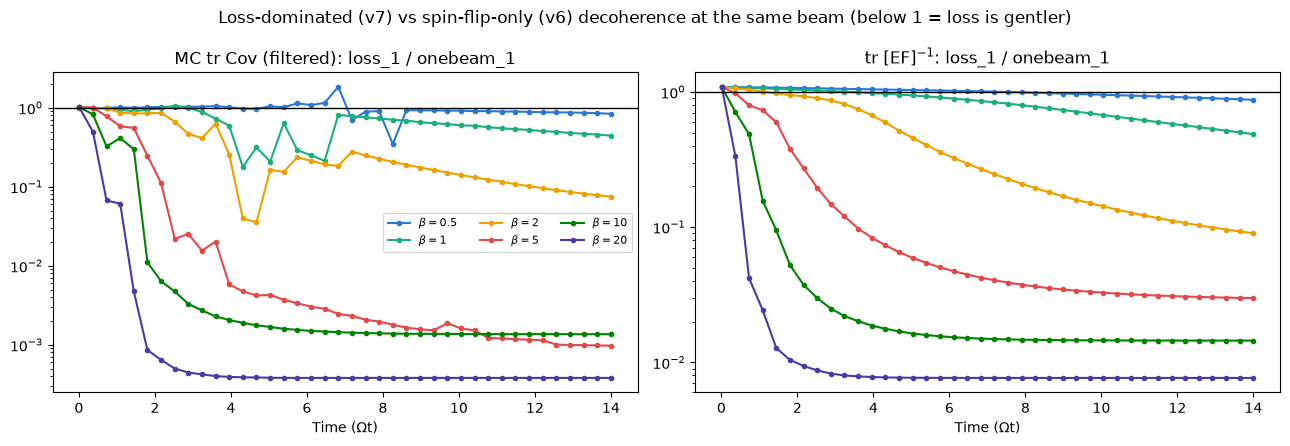

sigma per beta, onebeam_1 vs loss_1: [0.1732 0.1225 0.0866 0.0548 0.0387 0.0274] [0.1807 0.1277 0.0903 0.0571 0.0404 0.0286]


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for b_idx, beta in enumerate(beta_values):
    c = beta_colors[b_idx % len(beta_colors)]
    axes[0].semilogy(times, main['tot_var'][b_idx]/OB['tot_var'][b_idx], 'o-', color=c, ms=3, label=fr'$\beta={beta:g}$')
    axes[1].semilogy(times, main['tot_fit'][b_idx]/OB['tot_fit'][b_idx], 'o-', color=c, ms=3, label=fr'$\beta={beta:g}$')
for ax, ttl in zip(axes, ['MC tr Cov (filtered): loss_1 / onebeam_1', r'tr [EF]$^{-1}$: loss_1 / onebeam_1']):
    ax.axhline(1, color='k', lw=1); ax.set_title(ttl); ax.set_xlabel(r'Time ($\Omega$t)')
axes[0].legend(ncol=3, fontsize=8)
fig.suptitle('Loss-dominated (v7) vs spin-flip-only (v6) decoherence at the same beam (below 1 = loss is gentler)')
plt.tight_layout(); plt.show()
print('sigma per beta, onebeam_1 vs loss_1:', np.round(OB['sn'], 4), np.round(main['sn'], 4))
